In [1]:
%load_ext autoreload
%autoreload 2

import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
import xarray as xr
import sys
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from scipy.optimize import curve_fit


# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM
plt.rcParams.update({'font.size': 14})  

tidy3dAPI = os.environ["API_TIDY3D_KEY"]
plt.rc('font', family='Arial')


In [2]:
file = rf"./data/20260420_ff_2172_elliptical_rods_n_3p4_schulz.h5"
data_loaded = read_hdf5_as_dict(file)
data_loaded.keys()

dict_keys(['cell_size', 'ff', 'n_values', 'raw_freqs', 'sizes', 'transmission_data', 'z_values'])

In [3]:
#Gap data 
gap_data = AM.read_hdf5_as_dict(rf"H:\codes\tidy3d\Notebooks\LSU Project\20250630 MPB Bands analysis\Data\gap_data.hdf5")
gap_edges=11.44/(gap_data["Elliptical"]["0.1507"]["gap_edges"][14])
print(gap_data["Elliptical"]["0.1507"]["n"])
print(gap_data["Elliptical"].keys())

[2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7]
dict_keys(['0.05', '0.1002', '0.1507', '0.1807', '0.1909', '0.2', '0.2103', '0.22', '0.2307', '0.2402', '0.2502', '0.2605', '0.2702', '0.2806', '0.3003', '0.3518', '0.4004', '0.5166', '0.55', '0.6006'])


In [4]:
# #Calculate charqacteristic length
# a_value_z100 = AM.get_a_from_h5_eps(rf"./structures/n_3.40/Schulz/AR Hole 2.5/ff_0p2172/ffh_0.225_dist/z_100/n_3.40_ffh_0.2204_ffr_0.1693_fforiginal_0.2172_z_100_2.h5",L=11.44)

In [5]:
# a_value_z5 = AM.get_a_from_h5_eps(rf"./structures/n_3.40/Schulz/AR Hole 2.5/ff_0p2172/ffh_0.225_dist/z_5/n_3.40_ffh_0.2187_ffr_0.1697_fforiginal_0.2172_z_5_3.h5",L=11.44)

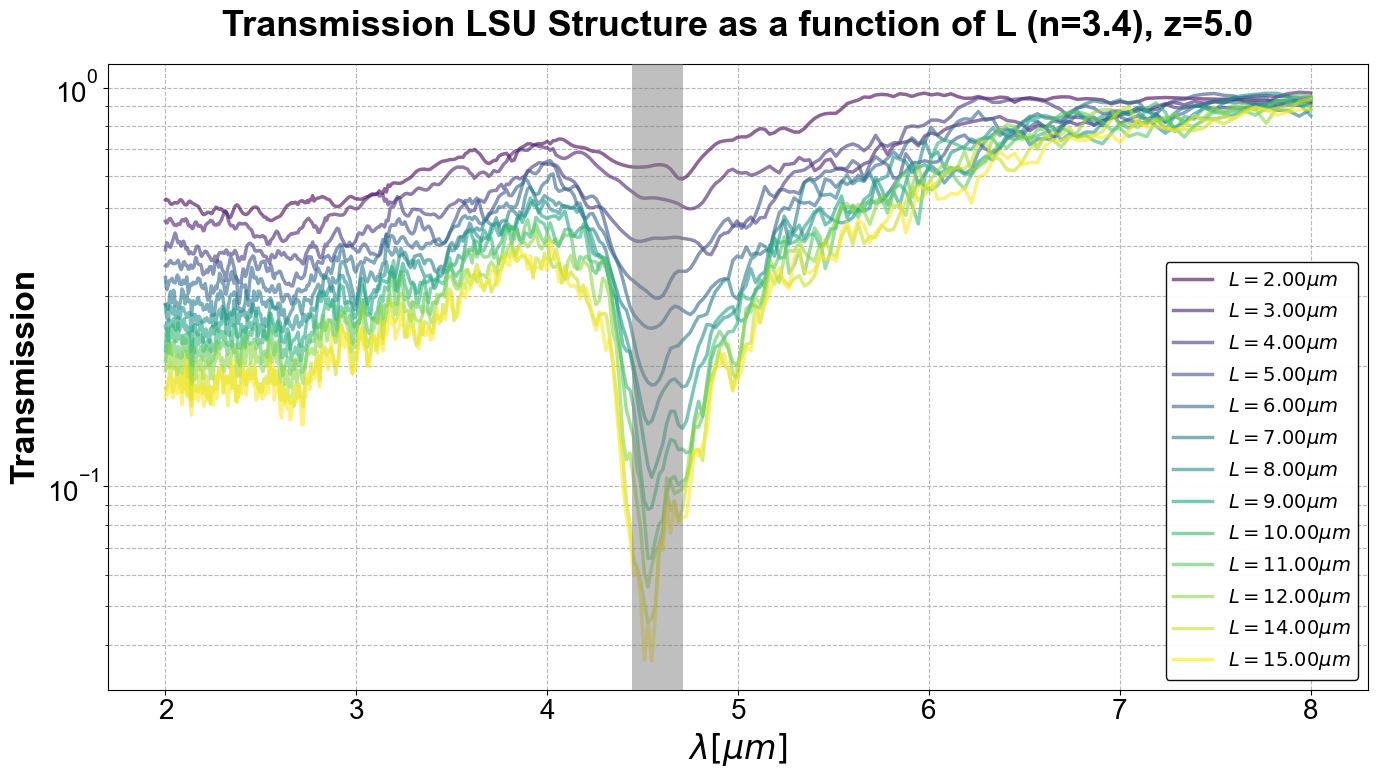

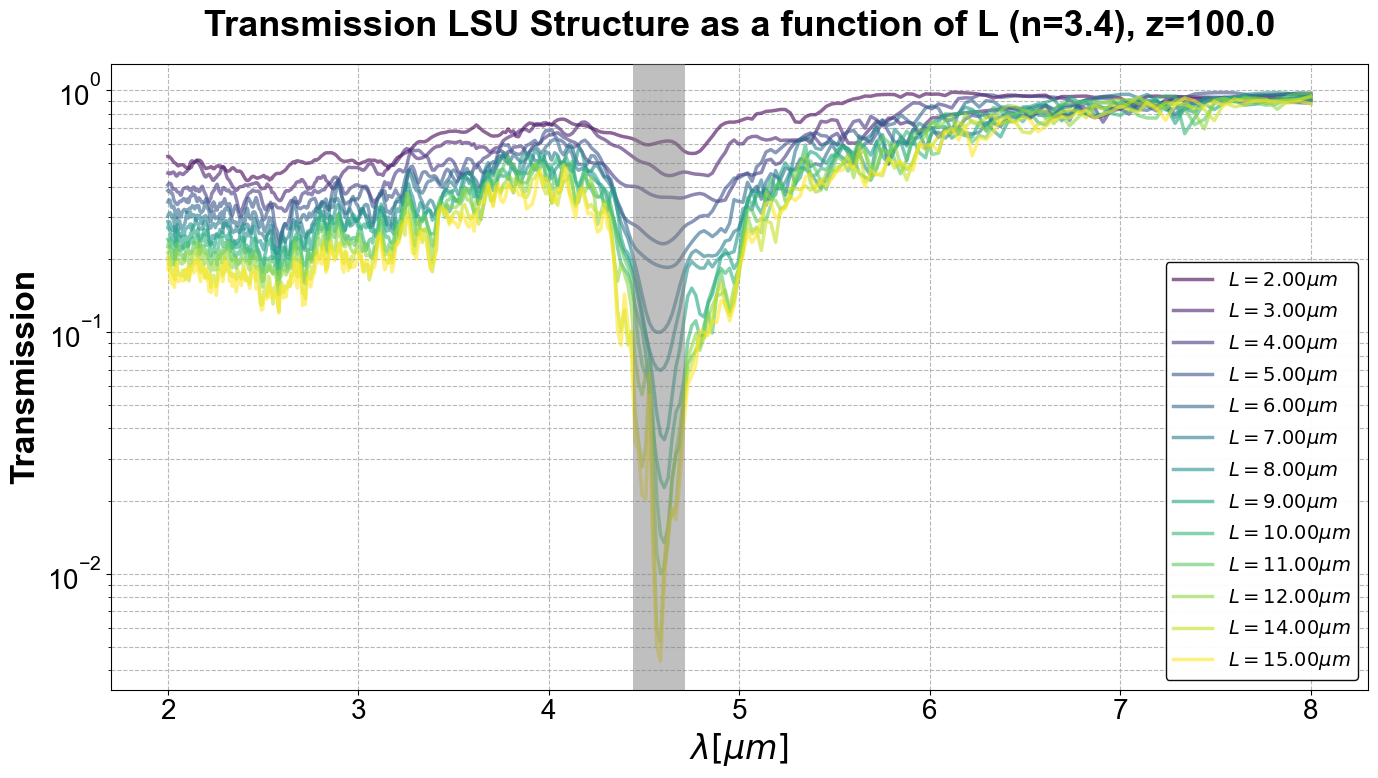

In [6]:
# Improved conference-quality plot
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
dir_path = './data/transmission_data'
os.makedirs(dir_path, exist_ok=True)
# Use a colormap that works well for presentations
colors = plt.cm.viridis(np.linspace(0, 1, len(data_loaded["sizes"])))

# Plot data and track what we've added to legend
line_styles = ['-', '--', '-.', ':']
for j, n in enumerate(data_loaded["n_values"]):
    for i, ff in enumerate(data_loaded["ff"]):
     transmission_z = []
     for l, z_value in enumerate(data_loaded["z_values"]):
        transmission_loop = []
        fig, ax = plt.subplots(figsize=(14, 8), dpi=100)
        for k, size in enumerate(data_loaded["sizes"]):
            wavelength = (td.C_0 / data_loaded["raw_freqs"])
            transmission = np.mean([data_loaded["transmission_data"][str(n)][str(ff)][str(z_value)][str(size)][rf"{q:.1f}"]["exit"] for q in range(5)],axis=0)
            # Create unique label only for each size
            label_key = rf"$L={size*11.44:.2f}\mu m$"
            label = label_key 
            
            # Use line style to differentiate n or ff values
            ls = line_styles[i % len(line_styles)] if len(data_loaded["ff"]) > 1 else '-'
            alpha = 0.6 + (j * 0.4 / max(len(data_loaded["n_values"]), 1))
       #      T_smooth = savgol_filter(transmission, window_length=15, polyorder=2)
       #      T_smooth = gaussian_filter1d(transmission, sigma=6)
            T_smooth = transmission
            transmission_loop.append(T_smooth)
            ax.plot(wavelength,T_smooth , label=label, color=colors[k], 
                   linewidth=2.5, linestyle=ls, alpha=alpha)
       #      ax.plot(wavelength,transmission,"--", label=label, color=colors[k], 
       #             linewidth=2.5, linestyle=ls, alpha=alpha)
            
        str_sizes = " ".join(str(s*11.44) for s in data_loaded["sizes"])
        transmission_array = np.array([wavelength] + transmission_loop)
        transmission_z+=[transmission_loop]
        np.savetxt(rf"{dir_path}/transmission_n_{n:.4f}_ff_{ff:.4f}_z_{z_value}_elliptical_average_5_samples.txt", np.transpose(transmission_array) , 
               fmt="%.18f", 
               delimiter=" ", 
               header="lambda " +str_sizes )

        # Styling for conference
        ax.set_yscale("log")
        ax.set_xlabel(rf"$\lambda[\mu m]$", fontsize=24, fontweight='bold')
        ax.set_ylabel("Transmission", fontsize=24, fontweight='bold')
        ax.set_title(rf"Transmission LSU Structure as a function of L (n={n}), z={z_value}", fontsize=26, fontweight='bold', pad=20)

        ax.grid(True, which="both", alpha=0.9, linestyle='--')
        ax.legend(loc='best', fontsize=14, framealpha=0.95, edgecolor='black')
        # Improve tick label size
        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.axvspan(gap_edges[0],gap_edges[1], facecolor='gray', alpha=0.5, edgecolor='none', zorder=1000, clip_on=False)

        # Add subtle background
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        plt.savefig(rf"{dir_path}/transmission_n_{n:.4f}_ff_{ff:.4f}_z_{z_value}_elliptical_average_5_samples.png")
        plt.tight_layout()
        plt.show()


In [10]:
from scipy.interpolate import interp1d

# Center of the photonic gap (midpoint between the two band edges)
lambda_gap = 0.5 * (gap_edges[0] + gap_edges[1])

# interp1d needs a monotonically increasing x-axis; wavelength is descending
# (freqs ascending), so sort once and reuse the order.
wl_sorted = wavelength
transmission_arr = np.array(transmission_z)          # (n_z, n_sizes, n_wl)
n_z, n_sizes, _ = transmission_arr.shape
min_transmission_gap = np.empty((n_z, n_sizes))

for iz in range(n_z):
    for isz in range(n_sizes):
        T = transmission_arr[iz, isz]
        # Smooth lightly to suppress speckle noise while keeping the gap shape.
        # Work in log space since transmission spans several decades.
        logT = np.log10(np.clip(T, 1e-300, None))
        logT_smooth = savgol_filter(logT, window_length=11, polyorder=3)
        f = interp1d(wl_sorted, logT_smooth, kind="cubic", bounds_error=False,
                     fill_value=(logT_smooth[0], logT_smooth[-1]))
        min_transmission_gap[iz, isz] = 10 ** f(lambda_gap)

print(f"Gap center wavelength: {lambda_gap:.4f} um")
min_transmission_gap.shape

Gap center wavelength: 4.5777 um


(2, 13)

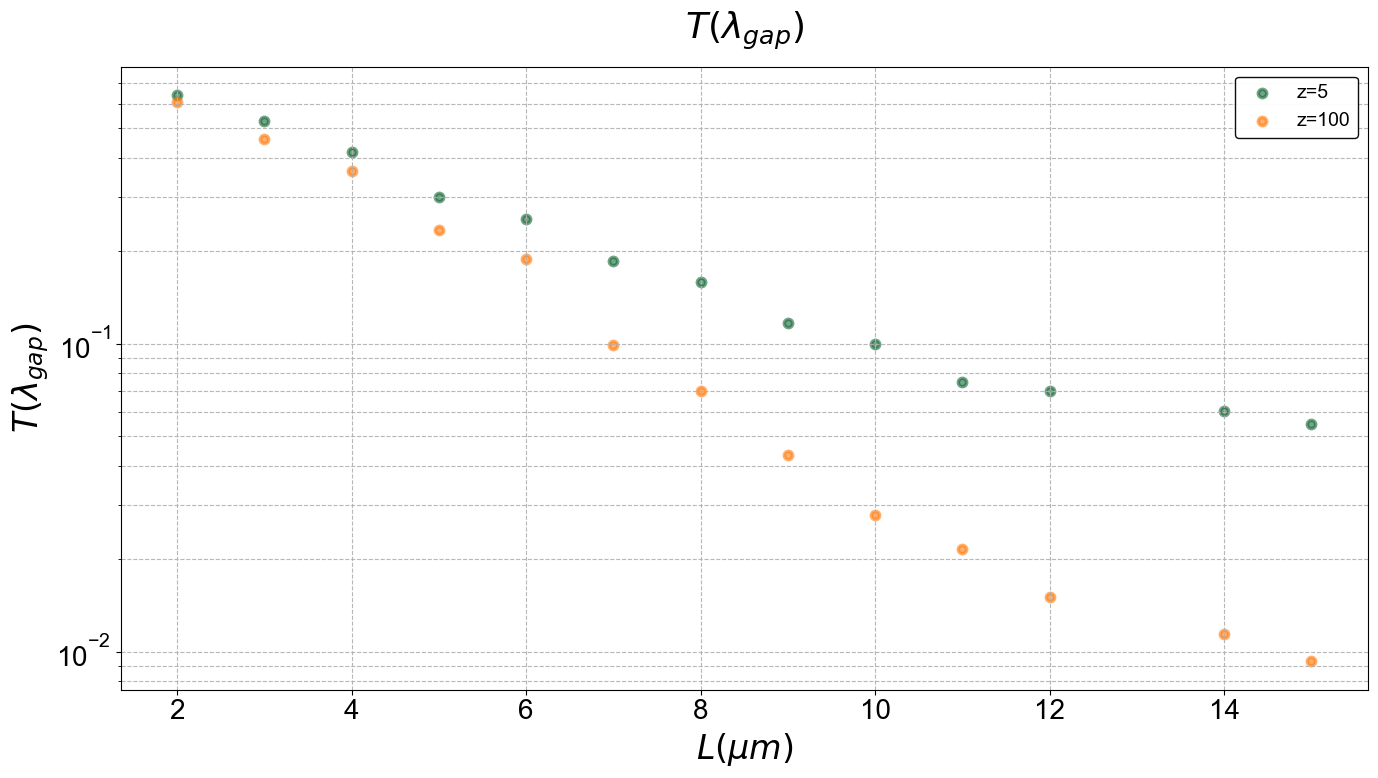

In [11]:
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)
ax.scatter(data_loaded["sizes"]*11.44, min_transmission_gap[0], label="z=5", 
                   linewidth=2.5, linestyle=ls, alpha=alpha)
ax.scatter(data_loaded["sizes"]*11.44, min_transmission_gap[1], label="z=100", 
                   linewidth=2.5, linestyle=ls, alpha=alpha)
ax.set_xlabel(rf"$L(\mu m)$", fontsize=24, fontweight='bold')
ax.set_ylabel(rf"$T(\lambda_{{gap}})$", fontsize=24, fontweight='bold')
ax.set_title(rf"$T(\lambda_{{gap}})$", fontsize=26, fontweight='bold', pad=20)
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=14, framealpha=0.95, edgecolor='black')
# Improve tick label size
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.yscale("log")
plt.savefig(rf"{dir_path}/transmission_n_{n:.4f}_ff_{ff:.4f}_transmission_gap.png")
plt.tight_layout()
plt.show()

In [12]:
sizes_list =np.array(list(np.ceil(s*11.44) for s in data_loaded["sizes"]))
data_text =np.append(sizes_list[None,:],min_transmission_gap, axis=0)
np.savetxt(rf"{dir_path}/transmission_n_{n:.4f}_ff_{ff:.4f}_lambda_gap.txt", np.transpose(data_text) , 
               fmt="%.18f", 
               delimiter=" ", 
               header="L,T_gap_z5,T_gap_z100" )